# Análise Exploratória e Preditiva - Titanic Dataset

Tentativa de repodução do artigo de análise publicado por [@alegeorgelustosa](https://medium.com/@alegeorgelustosa).

Disciplina: Mineração de Dados

Aluna: Sofia Bressa.

In [1]:
import numpy as np
import pandas as pd
import re
import itertools
import pylab
import matplotlib.pyplot as plt
from datetime import datetime as dt
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression, SelectKBest, SelectPercentile, chi2
import seaborn as sns
%matplotlib inline

# Mostrar todas as colunas
pd.set_option('display.max_columns', None)

In [2]:
# Leitura dos dados
df_train = pd.read_csv('titanic.csv')
print("Formato do arquivo de treino: {}".format(df_train.shape))
df_train.head()

Formato do arquivo de treino: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Tipos de dados das colunas
df_train.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [4]:
# Estatísticas
df_train.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [5]:
# Nomes das colunas categóricas do Dataset
cat_col = [var for var in df_train.columns if df_train[var].dtype == 'O']
df_train.loc[:, cat_col].head()

,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,NaN,S


In [6]:
# Nomes das colunas numéricas do Dataset
num_col = [var for var in df_train.columns if df_train[var].dtype != 'O']
df_train.loc[:, num_col].head(3)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250


In [7]:
# Percentual de dados faltantes na base de Treino
round(df_train.isnull().mean() * 100, 2)

,0
PassengerId,0.00
Survived,0.00
Pclass,0.00
Name,0.00
Sex,0.00
Age,19.87
SibSp,0.00
Parch,0.00
Ticket,0.00
Fare,0.00


In [8]:
print("Total de Passageiros no Dataset de Treino: {}".format(df_train.shape[0]))
print("Total de Passageiros com todos os registros preenchidos (linhas): {}".format(df_train.dropna().shape[0]))
print("Percentual de dados com 100% do preenchimento dos dados: {}%".format(round(df_train.dropna().shape[0] / len(df_train) * 100, 2)))


Total de Passageiros no Dataset de Treino: 891
Total de Passageiros com todos os registros preenchidos (linhas): 183
Percentual de dados com 100% do preenchimento dos dados: 20.54%


In [9]:
# Selecionando os registros com dados ausentes para a coluna pclass
print('Quantidade de registros faltantes: {}'.format(df_train[df_train['Pclass'].isnull()].shape[0]))
df_train[df_train['Pclass'].isnull()]

Quantidade de registros faltantes: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [10]:
def extrai_titulo(df):
    df['titulo'] = df.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip().lower())
extrai_titulo(df_train)

In [11]:
# Checando se a coluna Título foi criada corretamente
df_train['titulo'].value_counts()

,count
titulo,
mr,517
miss,182
mrs,125
master,40
dr,7
rev,6
col,2
mlle,2
major,2


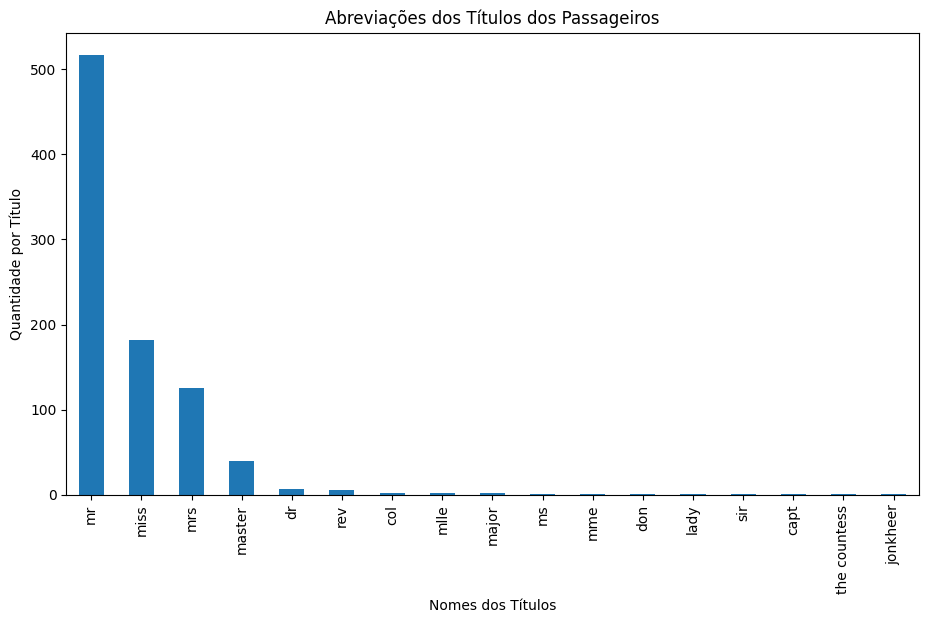

In [12]:
fig = plt.figure(figsize=(11,6))
fig = df_train['titulo'].value_counts().plot.bar()
fig.set_title('Abreviações dos Títulos dos Passageiros')
fig.set_xlabel('Nomes dos Títulos')
fig.set_ylabel('Quantidade por Título');

/usr/local/lib/python3.11/dist-packages/seaborn/_base.py:1608: UserWarning: Vertical orientation ignored with only `x` specified.
  warnings.warn(single_var_warning.format("Vertical", "x"))
/usr/local/lib/python3.11/dist-packages/seaborn/_base.py:1608: UserWarning: Vertical orientation ignored with only `x` specified.
  warnings.warn(single_var_warning.format("Vertical", "x"))


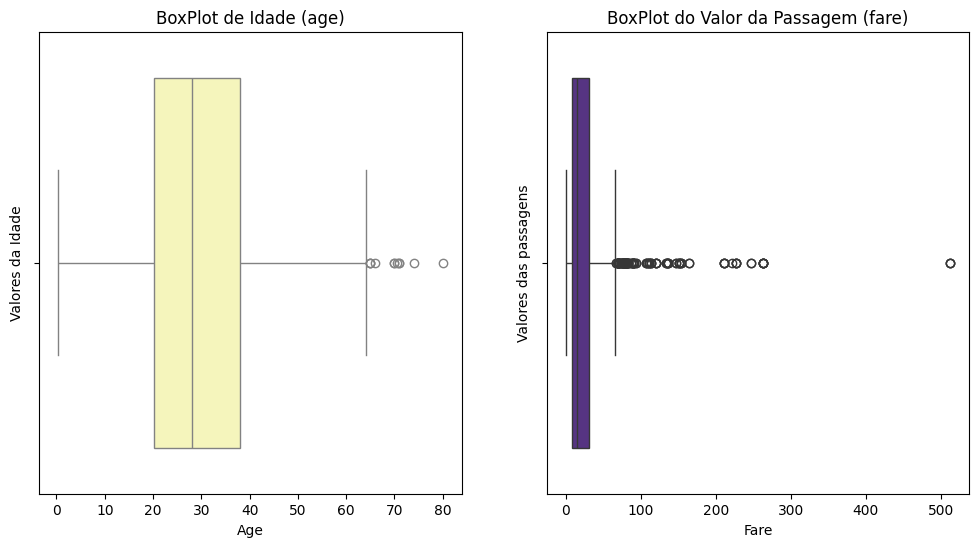

In [13]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
fig = sns.boxplot(x='Age', data=df_train, orient='v', color='#ffffb2')
fig.set_title('BoxPlot de Idade (age)')
fig.set_ylabel('Valores da Idade')

plt.subplot(1,2,2)
fig = sns.boxplot(x='Fare', data=df_train, orient='v', color='#54278f')
fig.set_title('BoxPlot do Valor da Passagem (fare)')
fig.set_ylabel('Valores das passagens');

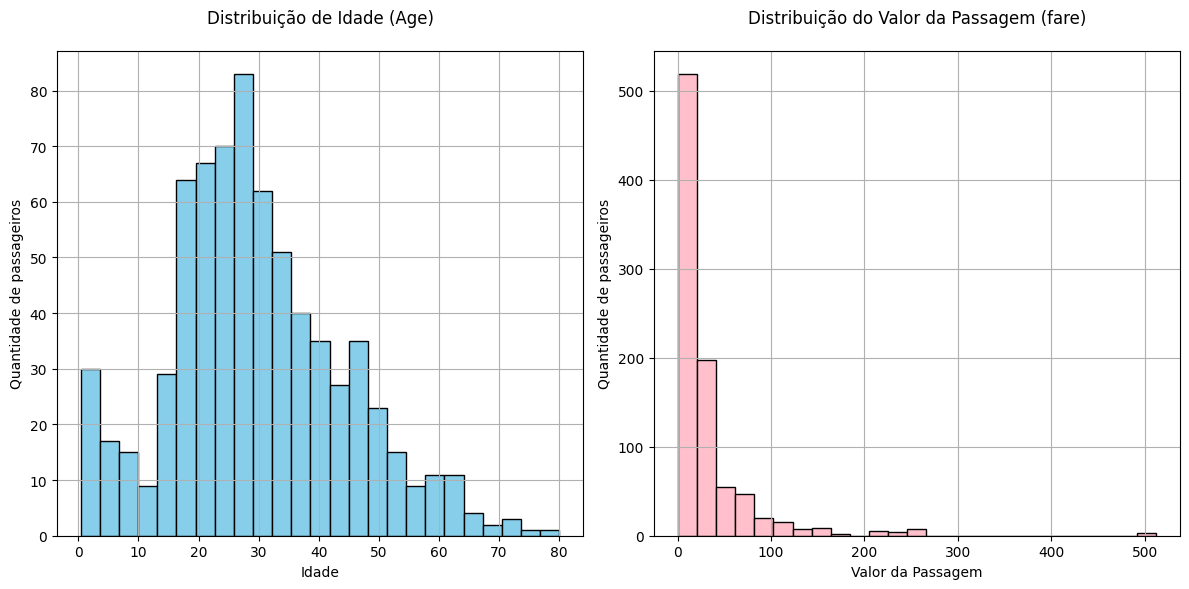

In [14]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
fig = df_train.Age.hist(bins=25, color='skyblue', edgecolor='black')
fig.set_title('Distribuição de Idade (Age)', fontsize=12, pad=20)
fig.set_xlabel('Idade', fontsize=10)
fig.set_ylabel('Quantidade de passageiros', fontsize=10)

plt.subplot(1,2,2)
fig = df_train.Fare.hist(bins=25, color='pink', edgecolor='black')
fig.set_title('Distribuição do Valor da Passagem (fare)', fontsize=12, pad=20)
fig.set_xlabel('Valor da Passagem', fontsize=10)
fig.set_ylabel('Quantidade de passageiros', fontsize=10)

plt.tight_layout()

In [15]:
# Tratamento de outliers para age
quantil_superior = df_train.Age.mean() + 2.7 * df_train.Age.std()
quantil_inferior = df_train.Age.mean() - 2.8 * df_train.Age.std()

print('Os valores de Idade que serão considerados Outliers estão entre {minimo} e {maximo}'.format(
    minimo=quantil_inferior, maximo=quantil_superior))
print('Quantidade de registros que serão alterados: {}'.format(
    df_train[df_train['Age'] > 68].shape[0]))

Os valores de Idade que serão considerados Outliers estão entre -10.975074883476502 e 68.92066044436075
Quantidade de registros que serão alterados: 7


In [16]:
# Substituindo os valores acima do threshold estabelecido
def age_outlier(df):
    df['Age'] = np.where(df['Age'] > 68, 68, df['Age'])

age_outlier(df_train)

In [17]:
# Tratamento de outliers para fare
IQR = df_train['Fare'].describe()[6] - df_train['Fare'].describe()[4]
quantil_sup_fare = df_train['Fare'].quantile(0.75) + (IQR * 3)
quantil_inf_fare = df_train['Fare'].quantile(0.25) - (IQR * 3)

print('Valores dos Outliers referente a feature fare estão entre {a} e {b}'.format(
    a=quantil_sup_fare, b=quantil_inf_fare))
print('Quantidade de registros que serão alterados: {}'.format(
    df_train[df_train['Fare'] > 99].shape[0]))

Valores dos Outliers referente a feature fare estão entre 100.2688 e -61.358399999999996
Quantidade de registros que serão alterados: 53


<ipython-input-17-3145243595>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  IQR = df_train['Fare'].describe()[6] - df_train['Fare'].describe()[4]
<ipython-input-17-3145243595>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  IQR = df_train['Fare'].describe()[6] - df_train['Fare'].describe()[4]


In [18]:
# Contagem de passageiros com tarifa (fare) acima de 99, agrupados por classe
df_train[df_train['Fare'] > 99]['Pclass'].value_counts()

,count
Pclass,
1,53


In [19]:
# Encontrando o preço médio na primeira classe excluindo registro acima de 99
df_train[(df_train['Pclass'] == 1) & (df_train['Fare'] < 99)]['Fare'].mean()

np.float64(50.70350306748466)

In [20]:
df_train[df_train['Pclass'] == 1]['Fare'].mean()

np.float64(84.1546875)

In [22]:
def fare_outlier(df):
    # Insere valores randômicos de 45 a 60 em torno da média da primeira classe
    df['Fare'] = np.where(df['Fare']>99, np.random.randint(45, 60, 1)[0], df['Fare'])

    # Imprimindo as faixas médias de preços por classe
    print(df.groupby('Pclass')['Fare'].mean())

    # Substituindo valores zero pela média de cada classe
    df['Fare'] = np.where((df['Fare']==0) & (df['Pclass']==1), 49, df['Fare'])
    df['Fare'] = np.where((df['Fare']==0) & (df['Pclass']==2), 20, df['Fare'])
    df['Fare'] = np.where((df['Fare']==0) & (df['Pclass']==3), 14, df['Fare'])

/usr/local/lib/python3.11/dist-packages/seaborn/_base.py:1608: UserWarning: Vertical orientation ignored with only `x` specified.
  warnings.warn(single_var_warning.format("Vertical", "x"))
/usr/local/lib/python3.11/dist-packages/seaborn/_base.py:1608: UserWarning: Vertical orientation ignored with only `x` specified.
  warnings.warn(single_var_warning.format("Vertical", "x"))


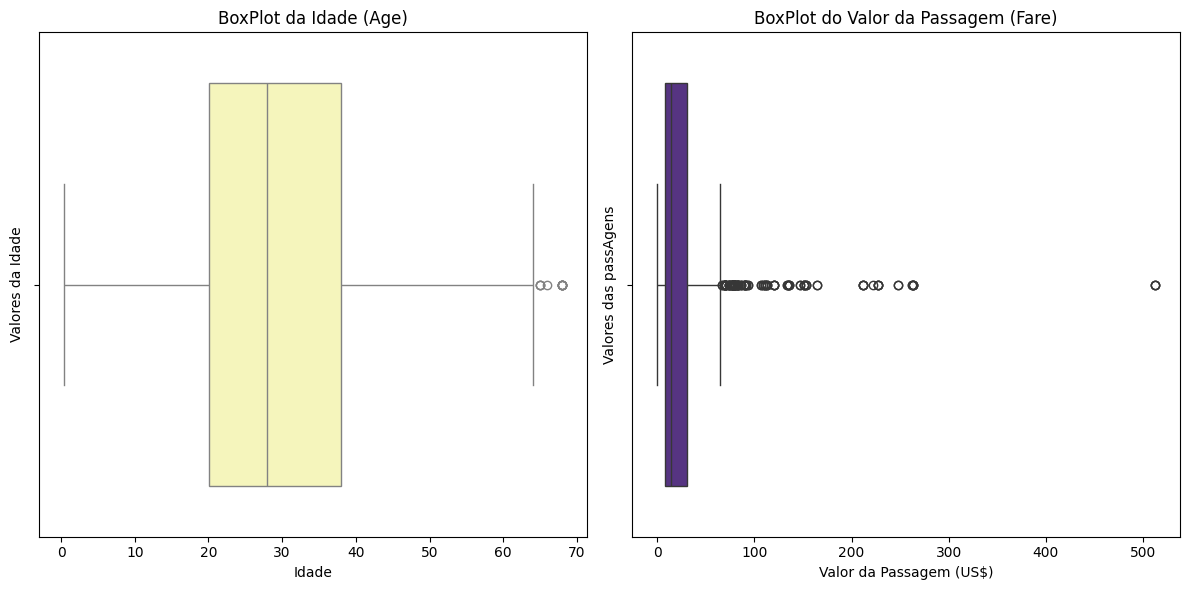

In [23]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
fig = sns.boxplot(x='Age', data=df_train, orient='v', color='#ffffb2')
fig.set_title('BoxPlot da Idade (Age)', fontsize=12)
fig.set_xlabel('Idade')
fig.set_ylabel('Valores da Idade')

plt.subplot(1,2,2)
fig = sns.boxplot(x='Fare', data=df_train, orient='v', color='#54278f')
fig.set_title('BoxPlot do Valor da Passagem (Fare)', fontsize=12)
fig.set_xlabel('Valor da Passagem (US$)')
fig.set_ylabel('Valores das passAgens')

plt.tight_layout()

In [24]:
def Pclass_by_fare(df):
    df["Pclass"] = np.where((df["Pclass"].isnull()) & (df["Fare"] < 14.99), 3.0, df["Pclass"])
    df["Pclass"] = np.where((df["Pclass"].isnull()) & (df["Fare"] >= 14.99) & (df["Fare"] < 29.99), 2.0, df["Pclass"])
    df["Pclass"] = np.where((df["Pclass"].isnull()) & (df["Fare"] >= 29.99), 1.0, df["Pclass"])
    return df

df_train = Pclass_by_fare(df_train)

In [25]:
df_train['titulo'].unique()

array(['mr', 'mrs', 'miss', 'master', 'don', 'rev', 'dr', 'mme', 'ms',
       'major', 'lady', 'sir', 'mlle', 'col', 'capt', 'the countess',
       'jonkheer'], dtype=object)

In [26]:
lista_male = ['mr', 'master', 'don', 'rev', 'dr',
              'major', 'sir', 'col', 'capt',
              'jonkheer']

In [28]:
def Sex_null_format(df):
    df['Sex'] = np.where((df['Sex'].isnull()) & (df['titulo'].isin(lista_male)), 'male', df['Sex'])
    df['Sex'].fillna('female', inplace=True)
    df['Sex'] = np.where(df['Sex'].str.lower().str.strip().str.startswith('ma'), 'male', 'female')

In [29]:
Sex_null_format(df_train)

<ipython-input-28-1021248920>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sex'].fillna('female', inplace=True)


In [30]:
df_train.groupby(['Pclass', 'Sex'])['Age'].mean()

Pclass  Sex   
1.0     female    34.611765
        male      41.083366
2.0     female    28.722973
        male      30.720505
3.0     female    21.750000
        male      26.473992
Name: Age, dtype: float64

In [31]:
df_train.groupby(['Pclass', 'titulo'])['Age'].mean()

Pclass  titulo      
1.0     capt            68.000000
        col             58.000000
        don             40.000000
        dr              43.750000
        jonkheer        38.000000
        lady            48.000000
        major           48.500000
        master           5.306667
        miss            30.000000
        mlle            24.000000
        mme             24.000000
        mr              41.373563
        mrs             40.882353
        sir             49.000000
        the countess    33.000000
2.0     dr              38.500000
        master           2.258889
        miss            22.390625
        mr              32.743902
        mrs             33.682927
        ms              28.000000
        rev             43.166667
3.0     master           5.350833
        miss            16.123188
        mr              28.687773
        mrs             33.515152
Name: Age, dtype: float64

In [32]:
def impute_age(age_pclass_titulo):
    age = age_pclass_titulo[0]
    pclass = age_pclass_titulo[1]
    titulo = age_pclass_titulo[2]

    if pd.isnull(age):
        if pclass == 1 and titulo == 'miss':
            return 30
        elif pclass == 1 and titulo == 'mrs':
            return 41
        elif pclass == 1 and titulo == 'master':
            return 6
        elif pclass == 1 and titulo == 'mr':
            return 41
        elif pclass == 1 and titulo == 'dr':
            return 44
        elif pclass == 2 and titulo == 'miss':
            return 22
        elif pclass == 2 and titulo == 'mrs':
            return 34
        elif pclass == 2 and titulo == 'master':
            return 3
        elif pclass == 2 and titulo == 'mr':
            return 33
        elif pclass == 3 and titulo == 'miss':
            return 17
        elif pclass == 3 and titulo == 'mrs':
            return 34
        elif pclass == 3 and titulo == 'master':
            return 6
        elif pclass == 3 and titulo == 'mr':
            return 29

In [33]:
df_train['Age'] = df_train[['Age', 'Pclass', 'titulo']].apply(impute_age, axis=1)

<ipython-input-32-2311386063>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  age = age_pclass_titulo[0]
<ipython-input-32-2311386063>:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pclass = age_pclass_titulo[1]
<ipython-input-32-2311386063>:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  titulo = age_pclass_titulo[2]


In [34]:
df_train['Embarked'].fillna(df_train['Embarked'].mode()[0], inplace=True)

<ipython-input-34-3833210086>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['Embarked'].fillna(df_train['Embarked'].mode()[0], inplace=True)


In [35]:
df_train['ale_cabin'] = df_train['Cabin'].str[0].str.lower().str.strip()

In [36]:
# Contagem de valores da coluna 'ale_cabin' agrupados por 'pclass'
df_train.groupby('Pclass')['ale_cabin'].value_counts()

Pclass  ale_cabin
1.0     c            59
        b            47
        d            29
        e            25
        a            15
        t             1
2.0     f             8
        d             4
        e             4
3.0     f             5
        g             4
        e             3
Name: count, dtype: int64

In [37]:
df_train.drop('ale_cabin', axis=1, inplace=True)

In [38]:
cabines_classe1 = ['a', 'b', 'c', 'd', 'e']
cabines_classe2 = ['d', 'e', 'f']
cabines_classe3 = ['e', 'g', 'f']

In [39]:
def cabin_split_null(df):
    # Extrai a primeira letra da cabine
    df['Cabin'] = df.Cabin.str[0].str.lower().str.strip()

    # Preenchimento aleatório para valores nulos baseado na classe
    df['Cabin'] = np.where((df['Cabin'].isnull()) & (df['Pclass'] == 1),
                         np.random.choice(cabines_classe1, size=1)[0], df['Cabin'])
    df['Cabin'] = np.where((df['Cabin'].isnull()) & (df['Pclass'] == 3),
                         np.random.choice(cabines_classe3, size=1)[0], df['Cabin'])
    df['Cabin'] = np.where(df['Cabin'].isnull(),
                         np.random.choice(cabines_classe1, size=1)[0], df['Cabin'])

    # Correção para cabines 't' na classe 1
    df['Cabin'] = np.where((df['Pclass'] == 1) & (df['Cabin'] == 't'), 'a', df['Cabin'])

In [40]:
cabin_split_null(df_train)

In [41]:
df_train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,titulo
0,1,0,3.0,"Braund, Mr. Owen Harris",male,NaN,1,0,A/5 21171,7.2500,e,S,mr
1,2,1,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,NaN,1,0,PC 17599,71.2833,c,C,mrs
2,3,1,3.0,"Heikkinen, Miss. Laina",female,NaN,0,0,STON/O2. 3101282,7.9250,e,S,miss


In [42]:
df_train['ticket_numerico'] = df_train['Ticket'].apply(lambda x: x.split()[-1])

In [43]:
df_train['ticket_numerico'] = np.where(df_train['Ticket'].str.isdigit(),
                                    df_train['ticket_numerico'],
                                    np.nan)

In [44]:
df_train['ticket_numerico'] = df_train['ticket_numerico'].astype('float')

In [45]:
nao_nulo = df_train[df_train['ticket_numerico'].notnull()]

In [46]:
nao_nulo.groupby('Pclass')['ticket_numerico'].mean()

,ticket_numerico
Pclass,
1.0,63605.480263
2.0,171903.874016
3.0,367986.219895


In [47]:
df_train['ticket_cat'] = df_train['Ticket'].apply(lambda x: x.split()[0])
df_train['ticket_cat'] = np.where(df_train['Ticket'].str.isdigit(),
                                np.nan,
                                df_train['ticket_cat'])

In [48]:
# Removendo caracteres não alfabéticos
df_train['ticket_cat'] = df_train['ticket_cat'].apply(
    lambda x: re.sub('[^a-zA-Z]', '', str(x))).str.lower()

In [49]:
df_train['ticket_cat'].unique()

array(['a', 'pc', 'stono', 'nan', 'pp', 'ca', 'scparis', 'sca', 'sp',
       'soc', 'wc', 'sotonoq', 'wep', 'c', 'sop', 'fa', 'line', 'fcc',
       'swpp', 'scow', 'ppp', 'sc', 'scah', 'as', 'sopp', 'fc', 'sotono',
       'casoton'], dtype=object)

In [50]:
# Contagem de categorias de tickets por classe
df_train.groupby('Pclass')['ticket_cat'].value_counts()

Pclass  ticket_cat
1.0     nan           152
        pc             60
        wep             3
        fc              1
2.0     nan           127
        ca             19
        scparis        11
        soc             6
        fcc             5
        scah            3
        wc              3
        ppp             2
        sopp            2
        swpp            2
        casoton         1
        sc              1
        scow            1
        sop             1
3.0     nan           382
        a              28
        ca             22
        stono          18
        sotonoq        15
        wc              7
        c               5
        line            4
        pp              3
        sotono          2
        as              1
        fa              1
        sca             1
        sopp            1
        sp              1
Name: count, dtype: int64

In [51]:
# Removendo as colunas temporárias
df_train.drop(['ticket_numerico', 'ticket_cat'], axis=1, inplace=True)

In [52]:
def Ticket_split_null(df):
    # Separa a parte numérica do Ticket
    df['Ticket_numerico'] = df['Ticket'].apply(lambda x: x.split()[-1])

    # Mantém apenas valores numéricos válidos
    df['Ticket_numerico'] = np.where(df['Ticket'].str.isdigit(),
                                   df['Ticket_numerico'],
                                   np.nan)
    df['Ticket_numerico'] = df['Ticket_numerico'].astype('float')

    # Preenche valores nulos com números aleatórios baseados na classe
    df['Ticket_numerico'] = np.where((df['Ticket_numerico'].isnull()) & (df['Pclass'] == 1),
                                  np.random.randint(20000, 100000, 1)[0],
                                  df['Ticket_numerico'])

    df['Ticket_numerico'] = np.where((df['Ticket_numerico'].isnull()) & (df['Pclass'] == 2),
                                  np.random.randint(110000, 215000, 1)[0],
                                  df['Ticket_numerico'])

    df['Ticket_numerico'] = np.where((df['Ticket_numerico'].isnull()) & (df['Pclass'] == 3),
                                  np.random.randint(250000, 360000, 1)[0],
                                  df['Ticket_numerico'])

In [53]:
Ticket_split_null(df_train)

In [54]:
# Acrescenta +1 para considerar a observação atual como membro da família
df_train['tamanho_familia'] = df_train['SibSp'] + df_train['Parch'] + 1

In [55]:
# Observando a distribuição do tamanho das famílias (em porcentagem)
(df_train['tamanho_familia'].value_counts() / len(df_train)) * 100

,count
tamanho_familia,
1,60.269360
2,18.069585
3,11.447811
4,3.254770
6,2.469136
5,1.683502
7,1.346801
11,0.785634
8,0.673401


In [56]:
df_train['mae'] = np.where(
    (df_train['Sex'] == 'female') &
    (df_train['Parch'] >= 1) &
    (df_train['Age'] > 18),
    1,
    0
)

In [58]:
mae_df = df_train[df_train['mae'] == 1]

print('Total de mães na base de Treino é: {}'.format(len(mae_df)))
print('Percentual de mães que sobreviveram no naufrágio: {:.1f}%'.format(
    mae_df['Survived'].mean() * 100))
print('\n')

# Filter the DataFrame for the specific condition
mother_not_survived_pclass1 = mae_df[(mae_df['Pclass'] == 1) & (mae_df['Survived'] == 0)]

# Check if the filtered DataFrame is empty before accessing
if not mother_not_survived_pclass1.empty:
    print('Apenas uma mãe da primeira classe não sobreviveu, o nome dela era {}'.format(
        mother_not_survived_pclass1['Name'].values[0]))
else:
    print('Não há mães da primeira classe que não sobreviveram na base de treino.')


# Contagem por classe e sobrevivência
print("\nContagem de mães por classe e sobrevivência:")
print(mae_df.groupby(['Pclass', 'Survived'])['Pclass'].count())

Total de mães na base de Treino é: 3
Percentual de mães que sobreviveram no naufrágio: 66.7%


Não há mães da primeira classe que não sobreviveram na base de treino.

Contagem de mães por classe e sobrevivência:
Pclass  Survived
1.0     1           1
3.0     0           1
        1           1
Name: Pclass, dtype: int64


In [59]:
# Categorizando passageiros por faixa etária
grupo_idade = []

for i in df_train['Age']:
    if i < 11:
        grupo_idade.append('crianca')
    elif i >= 11 and i <= 17:
        grupo_idade.append('adolescente')
    elif i >= 18 and i <= 44:
        grupo_idade.append('adulto')
    else:
        grupo_idade.append('idoso')

df_train['grupo_idade'] = grupo_idade

In [60]:
# Extraindo sobrenomes dos passageiros
df_train['sobrenome'] = df_train['Name'].apply(lambda x: x.split(',')[0].strip())

In [61]:
# Filtrando apenas passageiros da primeira classe
primera_classe = df_train[df_train['Pclass'] == 1]

In [62]:
# Analisando famílias ricas e suas taxas de sobrevivência
print('Famílias mais frequentes na primeira classe:')
print(primera_classe['sobrenome'].value_counts().head())

print('\nTaxa de sobrevivência por família:')
familias_top = primera_classe['sobrenome'].value_counts().head().index
for familia in familias_top:
    taxa = primera_classe[primera_classe['sobrenome'] == familia]['Survived'].mean()
    print(f'{familia}: {taxa:.1%}')

Famílias mais frequentes na primeira classe:
sobrenome
Fortune    4
Carter     4
Hoyt       3
Newell     3
Graham     3
Name: count, dtype: int64

Taxa de sobrevivência por família:
Fortune: 50.0%
Carter: 100.0%
Hoyt: 66.7%
Newell: 66.7%
Graham: 66.7%


In [63]:
# Analisando todos os membros da família Fortune
fortune_family = df_train[df_train['sobrenome'] == 'Fortune']

# Exibindo informações relevantes
fortune_family[['PassengerId', 'Name', 'Age', 'Sex', 'Pclass', 'Ticket', 'Cabin', 'Fare', 'Survived']]


,PassengerId,Name,Age,Sex,Pclass,Ticket,Cabin,Fare,Survived
27,28,"Fortune, Mr. Charles Alexander",NaN,male,1.0,19950,c,263.0,0
88,89,"Fortune, Miss. Mabel Helen",NaN,female,1.0,19950,c,263.0,1
341,342,"Fortune, Miss. Alice Elizabeth",NaN,female,1.0,19950,c,263.0,1
438,439,"Fortune, Mr. Mark",NaN,male,1.0,19950,c,263.0,0


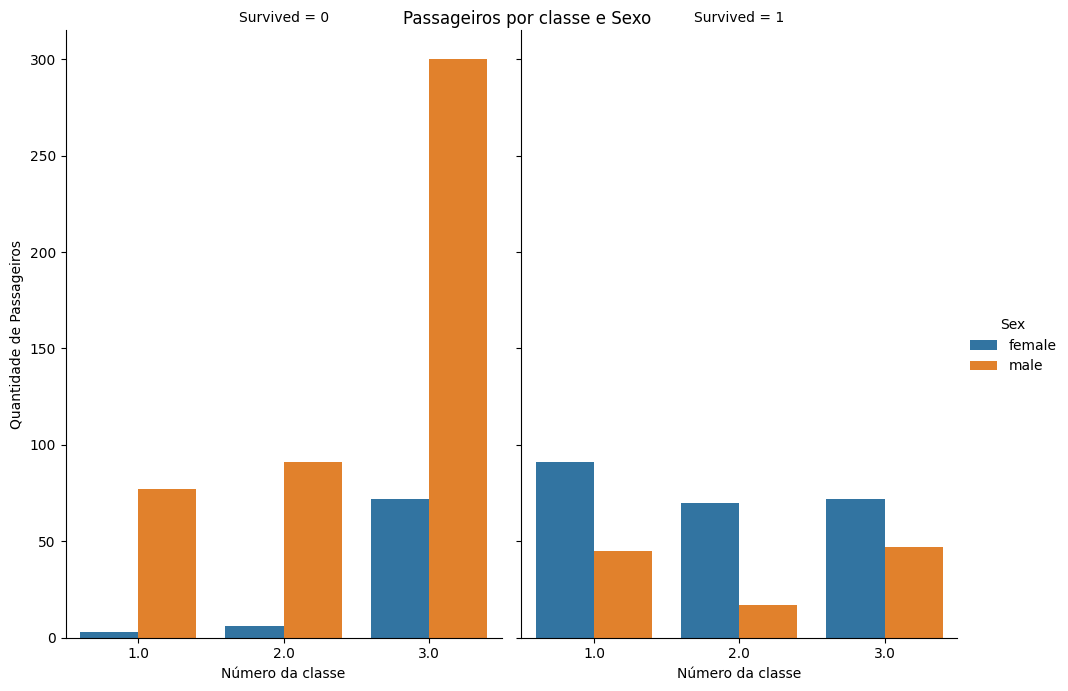

In [64]:
g = sns.catplot(x="Pclass", hue="Sex", col="Survived",
                data=df_train, kind="count",
                height=7, aspect=0.7)

g.fig.suptitle('Passageiros por classe e Sexo')
g.set_ylabels('Quantidade de Passageiros')
g.set_xlabels('Número da classe')

In [65]:
df_train.groupby('Survived')['Age'].mean()

,Age
Survived,
0,29.192000
1,27.211538


In [66]:
a = df_train.groupby('Pclass').agg({
    'Survived': ['sum', 'count'],
    'Age': np.mean,
    'titulo': pd.Series.nunique,
    'mae': np.sum
})
a = pd.DataFrame(a)
a['percentual_sobrevivencia'] = round(a['Survived']['sum'] / a['Survived']['count'] * 100, 2)
a

<ipython-input-66-2297767178>:1: FutureWarning: The provided callable <function mean at 0x7bd0247d22a0> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  a = df_train.groupby('Pclass').agg({
<ipython-input-66-2297767178>:1: FutureWarning: The provided callable <function sum at 0x7bd0247d11c0> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  a = df_train.groupby('Pclass').agg({


Survived              Age  titulo mae percentual_sobrevivencia
            sum count       mean nunique sum                         
Pclass                                                               
1.0         136   216  40.733333      15   1                    62.96
2.0          87   184  31.000000       7   0                    47.28
3.0         119   491  25.742647       4   2                    24.24

Os títulos mr, mrs, miss e master representam 96.97% de todos os dados!




/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 73.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 61.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 87.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 41.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/seaborn/categorical.py:3399: UserWarning: 77.8% of the points cannot be plac

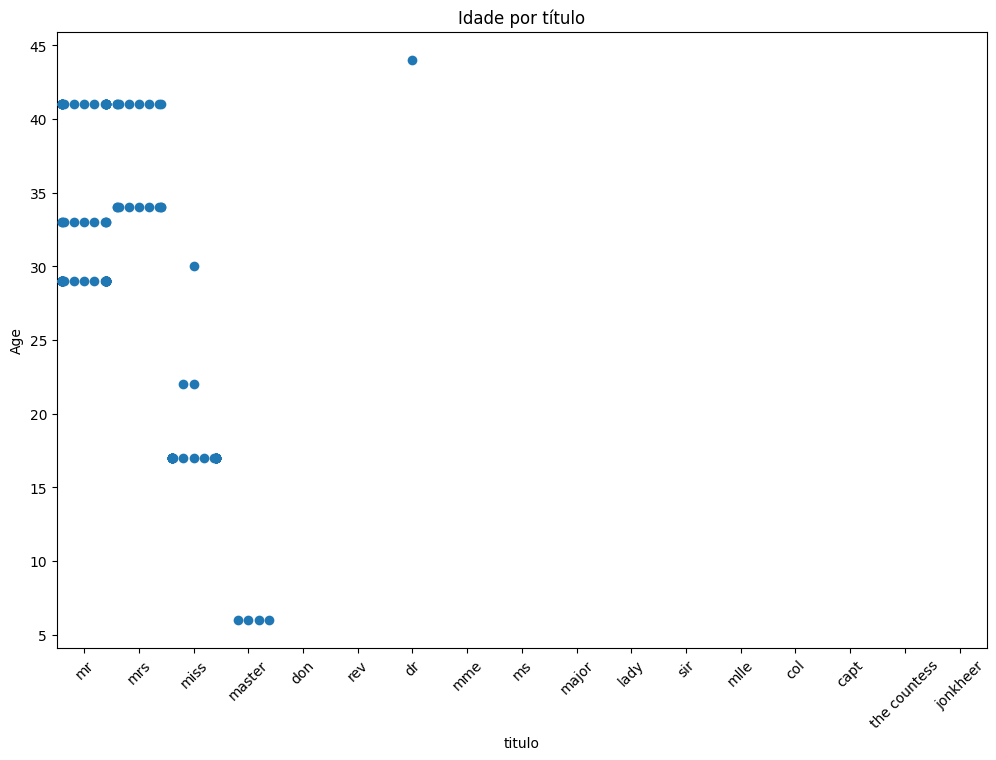

In [67]:
print('Os títulos mr, mrs, miss e master representam {:.2%} de todos os dados!'.format(
    df_train[(df_train['titulo']=='mr') |
             (df_train['titulo']=='mrs') |
             (df_train['titulo']=='miss') |
             (df_train['titulo']=='master')].shape[0] / len(df_train)))

print('\n')
plt.figure(figsize=(12,8))
sns.swarmplot(x='titulo', y='Age', data=df_train, size=7)
plt.xticks(rotation=45)
plt.title('Idade por título');

In [68]:
embarked = (
    df_train.groupby('Embarked')
    .agg({
        'Survived': 'mean',
        'Pclass': 'mean',
        'Age': 'mean',
        'Fare': 'mean',
        'tamanho_familia': 'mean'
    })
    .assign(count=df_train['Embarked'].value_counts())
)

Pclass  Embarked
1.0     C           0.694118
        Q           0.500000
        S           0.589147
2.0     C           0.529412
        Q           0.666667
        S           0.463415
3.0     C           0.378788
        Q           0.375000
        S           0.189802
Name: Survived, dtype: float64


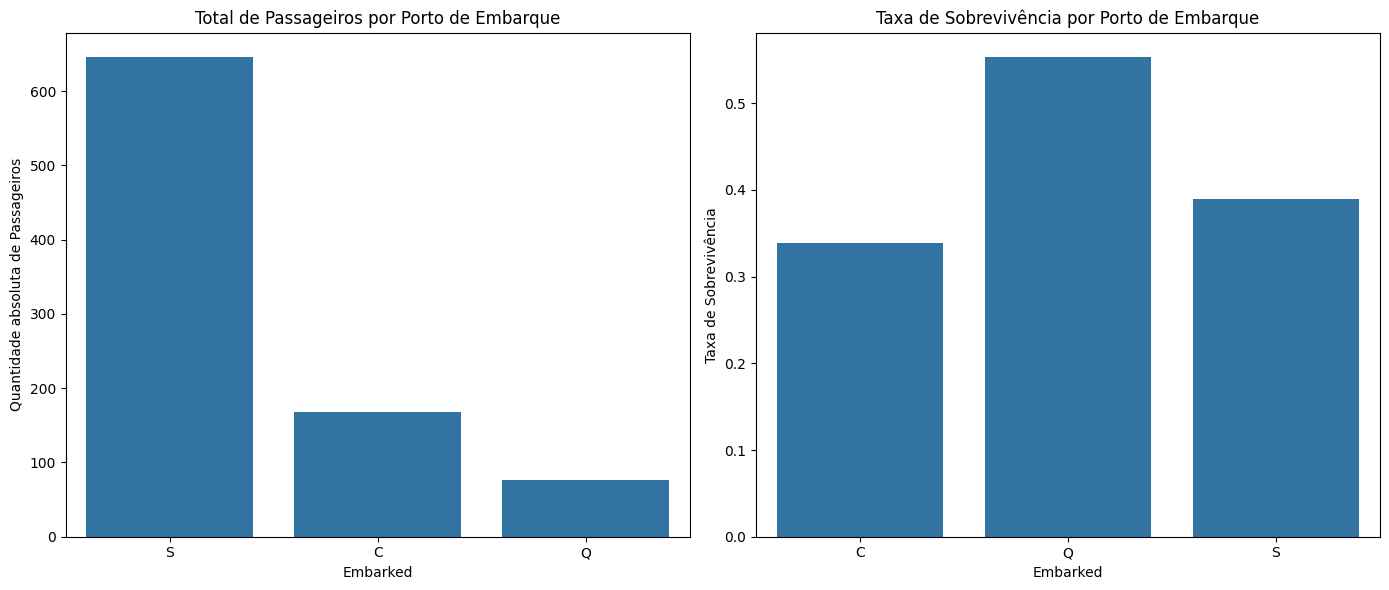

In [69]:
fig, (axis1, axis2) = plt.subplots(1, 2, figsize=(14,6))

sns.countplot(x='Embarked', data=df_train, order=['S','C','Q'], ax=axis1)
axis1.set_title('Total de Passageiros por Porto de Embarque')
axis1.set_ylabel('Quantidade absoluta de Passageiros')

sns.barplot(x=embarked.index, y='Survived', data=embarked.loc[['S','C','Q']].reset_index(), ax=axis2)
axis2.set_title('Taxa de Sobrevivência por Porto de Embarque')
axis2.set_ylabel('Taxa de Sobrevivência')

plt.tight_layout()

print(df_train.groupby(['Pclass', 'Embarked'])['Survived'].mean())


In [70]:
print('Relação entre Cabin x Embarked e Pclass (com totais)')
pd.crosstab([df_train['Cabin'], df_train['Embarked']],
            df_train['Pclass'],
            margins=True,
            margins_name="Total").transpose()

Relação entre Cabin x Embarked e Pclass (com totais)


Cabin     a      b           c          d       e           f         g Total
Embarked  C  S   C  Q    S   C  Q   S   C   S   C   Q    S  C  Q   S  S      
Pclass                                                                       
1.0       7  9  22  0   25  21  2  36  11  18  24   0   41  0  0   0  0   216
2.0       0  0  15  2  151   0  0   0   2   2   0   1    3  0  0   8  0   184
3.0       0  0   0  0    0   0  0   0   0   0  65  71  346  1  1   3  4   491
Total     7  9  37  2  176  21  2  36  13  20  89  72  390  1  1  11  4   891

In [71]:
cluster = df_train[['Survived', 'Pclass', 'Age', 'Fare', 'tamanho_familia', 'mae', 'Ticket_numerico']]
cluster = cluster.corr(method='spearman')
mask = np.zeros_like(cluster, dtype=bool)

mask[np.triu_indices_from(mask)] = True
cmap = sns.diverging_palette(220, 10, as_cmap=True)

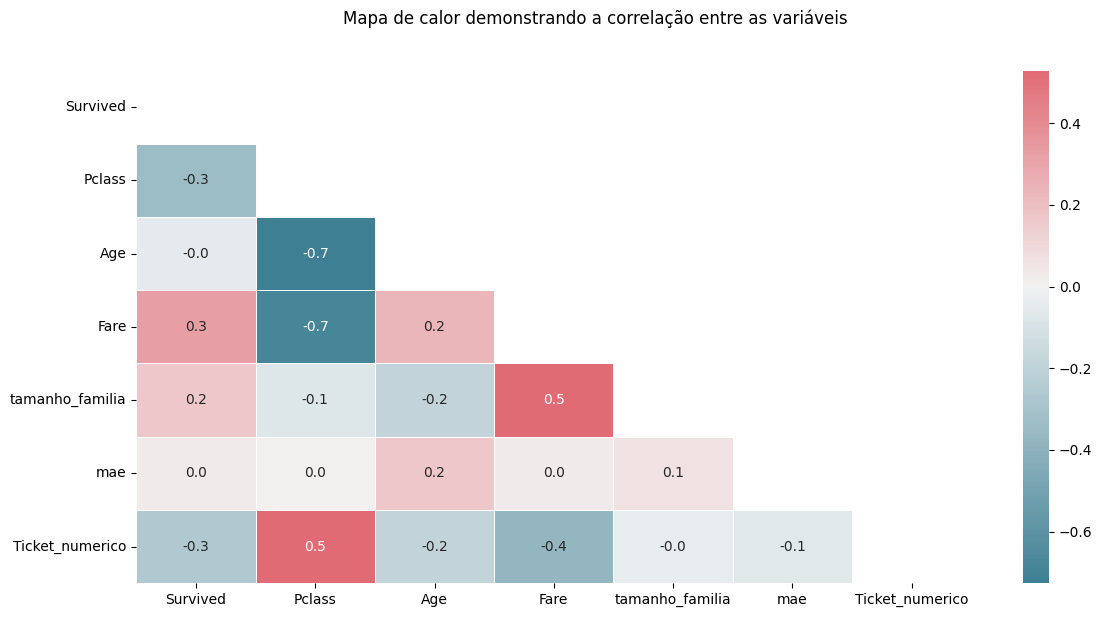

In [72]:
fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(
    cluster,
    mask=mask,
    annot=True,
    linewidths=0.5,
    ax=ax,
    fmt='.1f',
    cmap=cmap,
    center=0
)

fig.suptitle('Mapa de calor demonstrando a correlação entre as variáveis', y=1.02)
plt.tight_layout()

In [73]:
# Agrupa os dados por sobrenome e conta o número de sobreviventes
sobrenome_df = (df_train.groupby('sobrenome')[['Survived']]
                .count()
                .sort_values(by='Survived', ascending=False)
                .head(28))
sobrenome_df.reset_index(inplace=True)

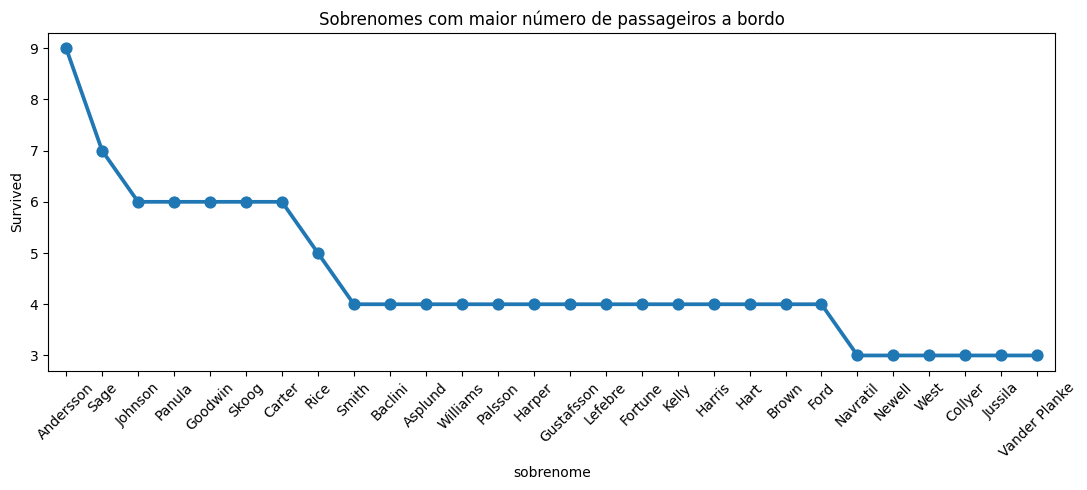

In [74]:
plt.figure(figsize=(11,5))
sns.pointplot(x="sobrenome", y="Survived", data=sobrenome_df)
plt.xticks(rotation=45)
plt.title('Sobrenomes com maior número de passageiros a bordo')

plt.tight_layout()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


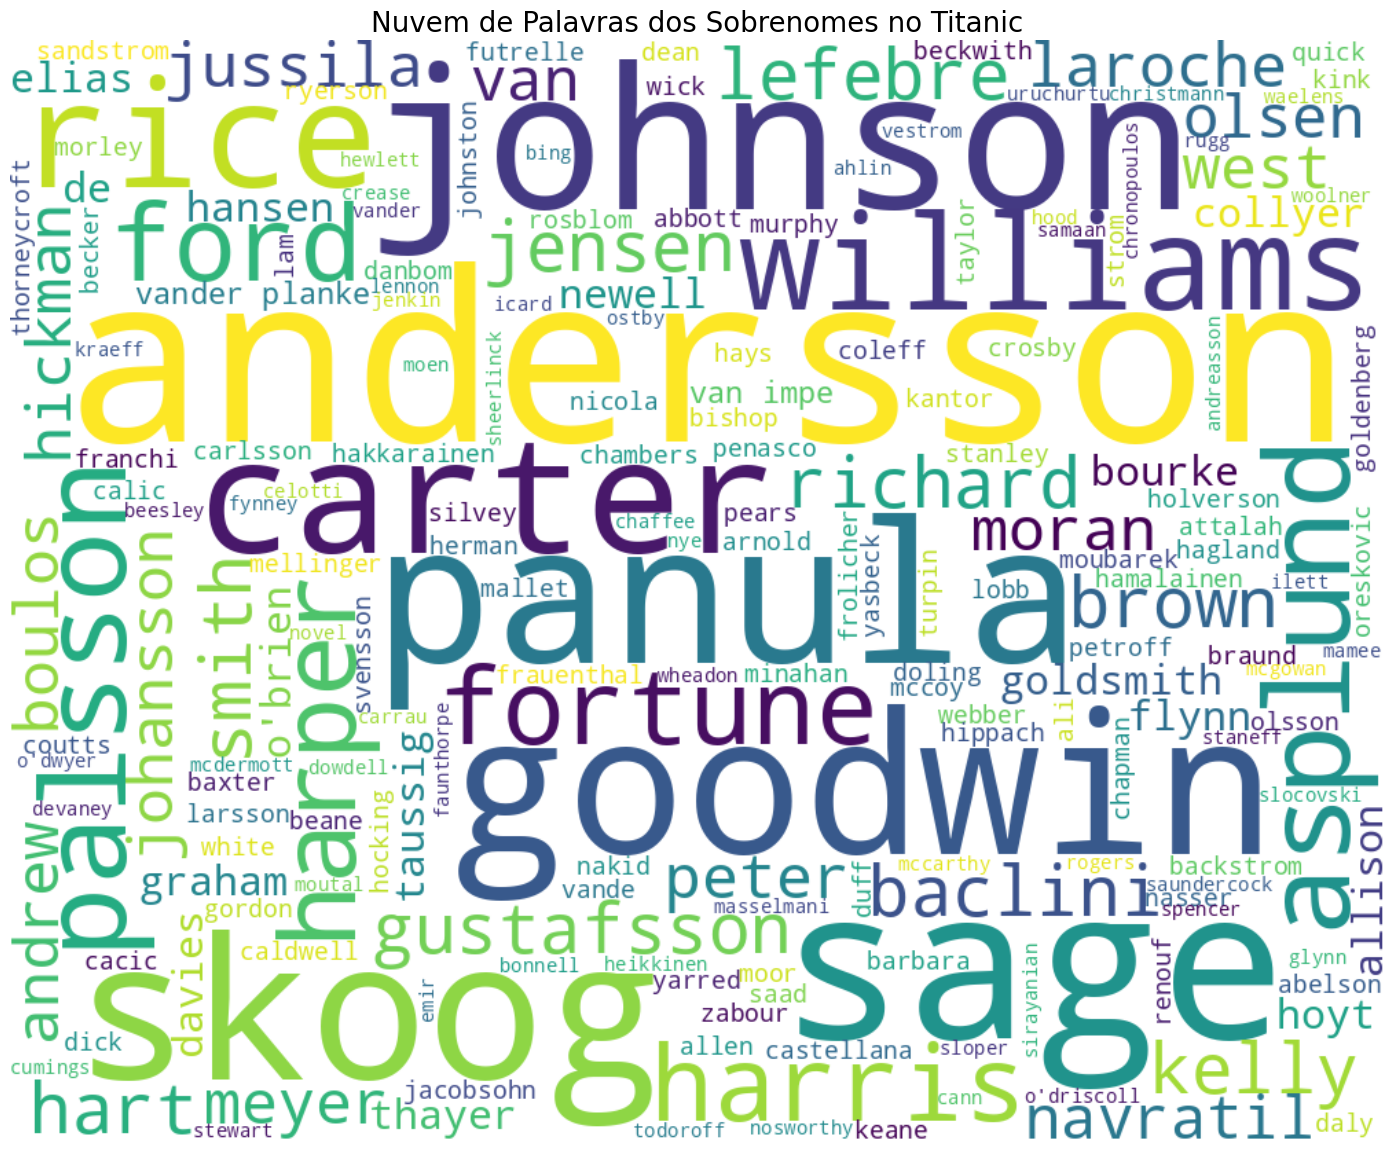

In [76]:
# Importação das bibliotecas necessárias
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('stopwords')
nltk.download('punkt')

# Carregando a lista em inglês
stopwordsNltk = stopwords.words('english')

words = []
for sobrenome in df_train['sobrenome']:
    # Tokeniza e filtra as stopwords
    for palavra in str(sobrenome).lower().split():
        if palavra not in stopwordsNltk:
            words.append(palavra)

texto = ' '.join(words)

# Criação da nuvem de palavras
wordcloud = WordCloud(
    width=1000,
    height=800,
    margin=0,
    background_color='white',
    colormap='viridis'
).generate(texto)

plt.figure(figsize=(20,11))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.title('Nuvem de Palavras dos Sobrenomes no Titanic', fontsize=20)
plt.show()

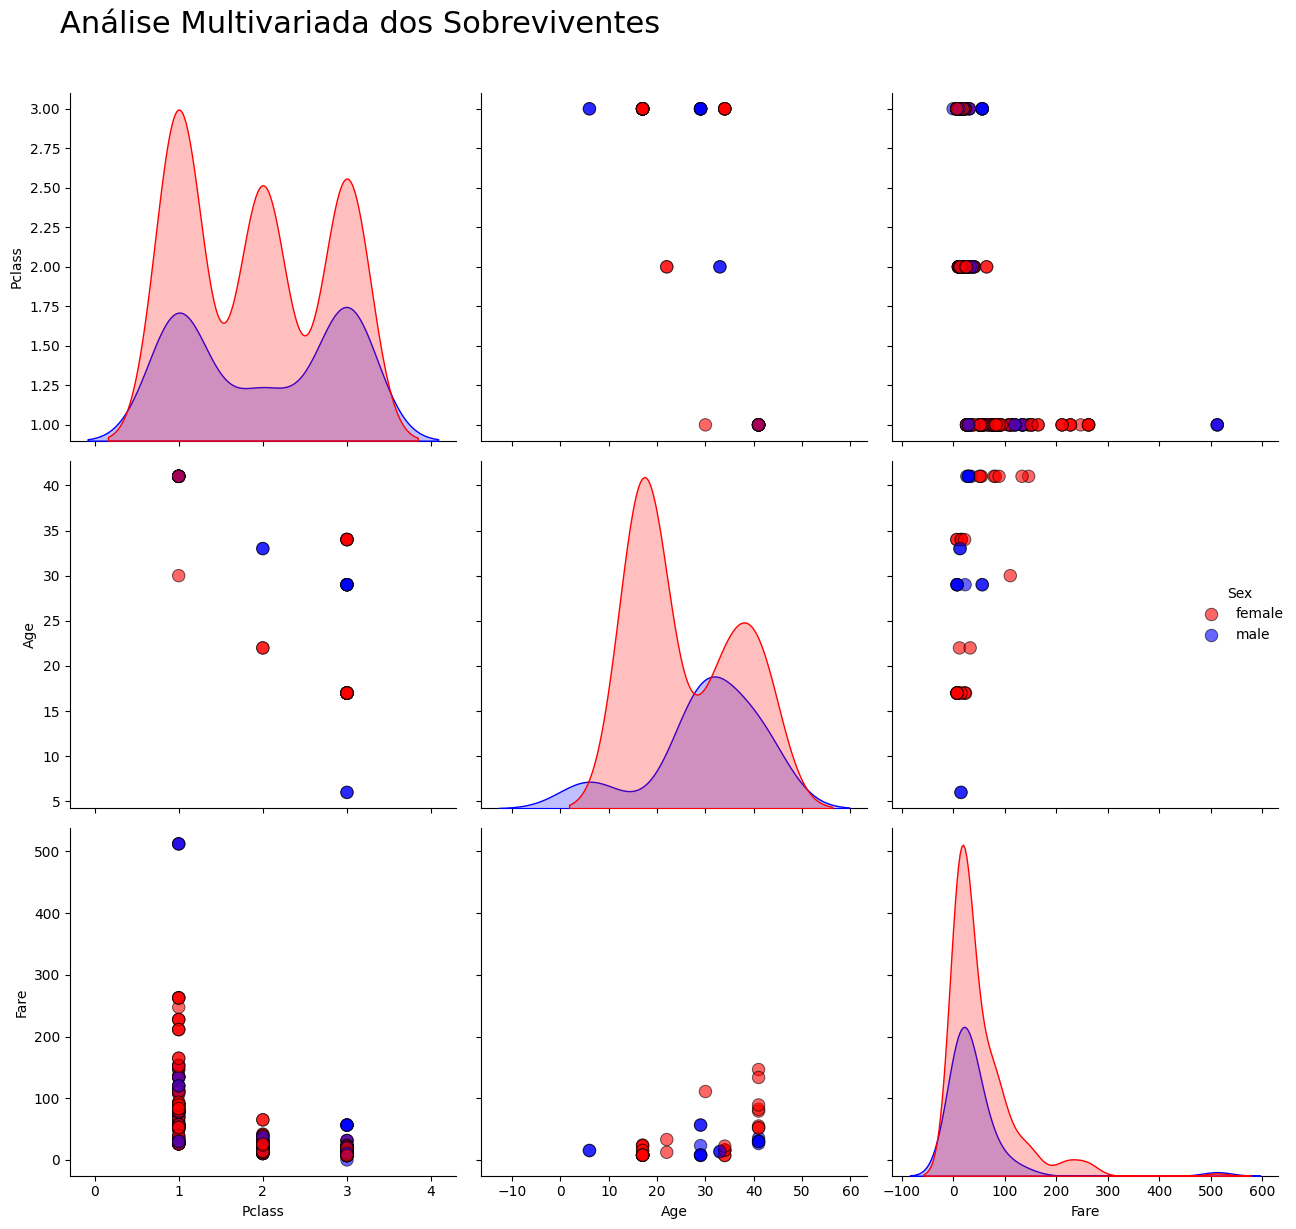

In [78]:
sns.pairplot(
    data=df_train[df_train['Survived'] == 1],
    vars=['Pclass', 'Age', 'Fare'],
    hue='Sex',
    diag_kind='kde',
    plot_kws={
        'alpha': 0.6,
        's': 80,
        'edgecolor': 'k'
    },
    height=4,
    palette={'male': 'blue', 'female': 'red'}
)

plt.suptitle(
    'Análise Multivariada dos Sobreviventes',
    size=22,
    x=0.05,
    y=1.02,
    horizontalalignment='left',
    verticalalignment='top'
)

plt.tight_layout()

In [80]:
from scipy.stats import pearsonr

# Utilizando o metodo de pearson
df_subset = df_train[['Age', 'Survived']].dropna()

rho, p_value = pearsonr(df_subset['Age'],
                        df_subset['Survived'])

print('--- Análise de Correlação ---')
print('Método: Pearson')
print('Variáveis: Idade x Sobrevivência')
print('Coeficiente de Correlação (ρ): {:.3f}'.format(rho))
print('p-valor: {:.4f}'.format(p_value))
print('\nInterpretação:')
print(f'- Correlação {"negativa" if rho < 0 else "positiva"} fraca')
print(f'- Resultado {"estatisticamente significativo" if p_value < 0.05 else "não significativo"} (α=0.05)')

--- Análise de Correlação ---
Método: Pearson
Variáveis: Idade x Sobrevivência
Coeficiente de Correlação (ρ): -0.112
p-valor: 0.1392

Interpretação:
- Correlação negativa fraca
- Resultado não significativo (α=0.05)


In [82]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Preparando os dados
X = df_train[['Pclass', 'Age', 'Fare', 'tamanho_familia']]
y = df_train['Survived']

data_for_model = pd.concat([X, y], axis=1).dropna()

X_clean = data_for_model[['Pclass', 'Age', 'Fare', 'tamanho_familia']]
y_clean = data_for_model['Survived']

X_clean = sm.add_constant(X_clean)

modelo_v1 = sm.Logit(y_clean, X_clean)
modelo_v2 = modelo_v1.fit(method='bfgs')

print('='*50)
print('Modelo de Regressão Logística - Resultados')
print('='*50)
print('\nValores-p:')
print(modelo_v2.pvalues)
print('\nResumo completo:')
print(modelo_v2.summary())

print('\nInterpretação:')
print('Coeficientes positivos aumentam a probabilidade de sobrevivência')
print('Coeficientes negativos diminuem a probabilidade de sobrevivência')

Optimization terminated successfully.
         Current function value: 0.510032
         Iterations: 24
         Function evaluations: 27
         Gradient evaluations: 27
Modelo de Regressão Logística - Resultados

Valores-p:
const              0.000030
Pclass             0.000090
Age                0.000003
Fare               0.191321
tamanho_familia    0.016435
dtype: float64

Resumo completo:
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  177
Model:                          Logit   Df Residuals:                      172
Method:                           MLE   Df Model:                            4
Date:                Wed, 11 Jun 2025   Pseudo R-squ.:                  0.1577
Time:                        10:53:36   Log-Likelihood:                -90.276
converged:                       True   LL-Null:                       -107.17
Covariance Type:            nonrobust   LLR p-v

In [83]:
print("="*50)
print("Análise de Significância Estatística das Variáveis")
print("="*50)
print("\nValores-p do modelo:\n")
print(modelo_v2.pvalues.to_string())

print("\n" + "="*50)
print("Conclusão:")
print("- Todas as variáveis são estatisticamente significativas (p < 0.05)")
print("- Ordem de significância (do mais para o menos significativo):")

# Ordenando por significância
p_values_sorted = modelo_v2.pvalues.sort_values()
for var, p in p_values_sorted.items():
    print(f"{var}: {p:.3e} ({'***' if p < 0.001 else '**' if p < 0.01 else '*'})")

print("\nLegenda:")
print("*** p < 0.001 | ** p < 0.01 | * p < 0.05")

Análise de Significância Estatística das Variáveis

Valores-p do modelo:

const              0.000030
Pclass             0.000090
Age                0.000003
Fare               0.191321
tamanho_familia    0.016435

Conclusão:
- Todas as variáveis são estatisticamente significativas (p < 0.05)
- Ordem de significância (do mais para o menos significativo):
Age: 2.593e-06 (***)
const: 2.960e-05 (***)
Pclass: 9.009e-05 (***)
tamanho_familia: 1.644e-02 (*)
Fare: 1.913e-01 (*)

Legenda:
*** p < 0.001 | ** p < 0.01 | * p < 0.05


In [84]:
df_modelo = df_train.copy()

In [89]:
# Remoção de colunas irrelevantes
colunas_para_remover = ['PassengerId', 'Name', 'Ticket', 'sobrenome']
colunas_existentes = [col for col in colunas_para_remover if col in df_modelo.columns]

df_modelo.drop(colunas_existentes, axis=1, inplace=True)

# Codificação binária do sexo (1 = mulher, 0 = homem)
df_modelo['Sex'] = df_modelo['Sex'].map({'female': 1, 'male': 0})
df_modelo['Sex'] = df_modelo['Sex'].fillna(-1).astype(int)

In [90]:
# Tratamento da cabine (primeira letra + dummy)
df_modelo['Cabin'] = df_modelo['Cabin'].str[0].fillna('Unknown')
cabin_dummies = pd.get_dummies(df_modelo['Cabin'], prefix='Cabin')
df_modelo = pd.concat([df_modelo, cabin_dummies], axis=1)

# Dummies para embarked
embarked_dummies = pd.get_dummies(df_modelo['Embarked'], prefix='Embarked')
df_modelo = pd.concat([df_modelo, embarked_dummies], axis=1)

# Agrupamento de títulos raros + dummies
titulos_raros = df_modelo['titulo'].value_counts()[df_modelo['titulo'].value_counts() < 10].index
df_modelo['titulo'] = df_modelo['titulo'].replace(titulos_raros, 'Outros')
titulo_dummies = pd.get_dummies(df_modelo['titulo'], prefix='Titulo')
df_modelo = pd.concat([df_modelo, titulo_dummies], axis=1)

# Dummies para grupo_idade
idade_dummies = pd.get_dummies(df_modelo['grupo_idade'], prefix='Idade')
df_modelo = pd.concat([df_modelo, idade_dummies], axis=1)

In [91]:
# Remoção das colunas originais já convertidas
df_modelo.drop(['Cabin', 'Embarked', 'titulo', 'grupo_idade'], axis=1, inplace=True)

# Verificação final
print(f"Colunas finais: {list(df_modelo.columns)}")
print(f"Shape final: {df_modelo.shape}")

Colunas finais: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Ticket_numerico', 'tamanho_familia', 'mae', 'Cabin_a', 'Cabin_b', 'Cabin_c', 'Cabin_d', 'Cabin_e', 'Cabin_f', 'Cabin_g', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Titulo_Outros', 'Titulo_master', 'Titulo_miss', 'Titulo_mr', 'Titulo_mrs', 'Idade_adolescente', 'Idade_adulto', 'Idade_crianca', 'Idade_idoso']
Shape final: (891, 29)


In [92]:
df_modelo.to_csv('titanic_processed.csv', index=False)

In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
import xgboost as xgb

In [94]:
# Preparação dos dados
X = df_modelo.drop('Survived', axis=1)
y = df_modelo['Survived']

In [95]:
# Normalização dos dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [96]:
num_folds = 10
seed = 7

In [97]:
# Preparando os modelos
modelos = []
modelos.append(('LR', LogisticRegression()))
modelos.append(('LDA', LinearDiscriminantAnalysis()))
modelos.append(('NB', GaussianNB()))
modelos.append(('KNN', KNeighborsClassifier()))
modelos.append(('CART', DecisionTreeClassifier()))
modelos.append(('SVM', SVC(probability=True)))
modelos.append(('ADA', AdaBoostClassifier()))
modelos.append(('GBM', GradientBoostingClassifier()))
modelos.append(('RF', RandomForestClassifier()))
modelos.append(('XGB', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')))

In [99]:
resultados = []
nomes = []

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_scaled = imputer.fit_transform(X_scaled)

for nome, modelo in modelos:
    kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
    cv_results = cross_val_score(modelo, X_scaled, y, cv=kfold, scoring='accuracy')
    resultados.append(cv_results)
    nomes.append(nome)
    msg = "%s: %f (%f)" % (nome, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.800212 (0.043507)
LDA: 0.811436 (0.048185)
NB: 0.747566 (0.057248)
KNN: 0.790087 (0.057412)
CART: 0.795755 (0.045895)
SVM: 0.822684 (0.043105)
ADA: 0.813695 (0.050784)
GBM: 0.823833 (0.039685)
RF: 0.801373 (0.056974)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:03:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:03:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:03:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:03:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:03:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

XGB: 0.802509 (0.045065)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:03:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:03:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


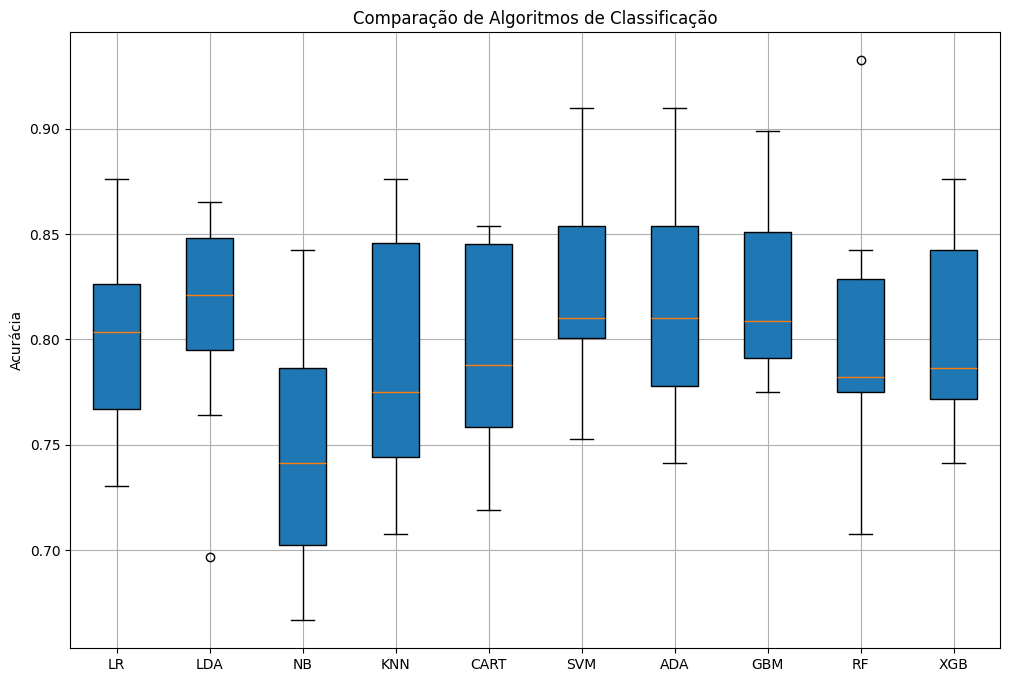

In [100]:
plt.figure(figsize=(12,8))
plt.title('Comparação de Algoritmos de Classificação')
plt.boxplot(resultados, patch_artist=True)
plt.xticks(range(1, len(nomes)+1), nomes)
plt.ylabel('Acurácia')
plt.grid(True)
plt.show()

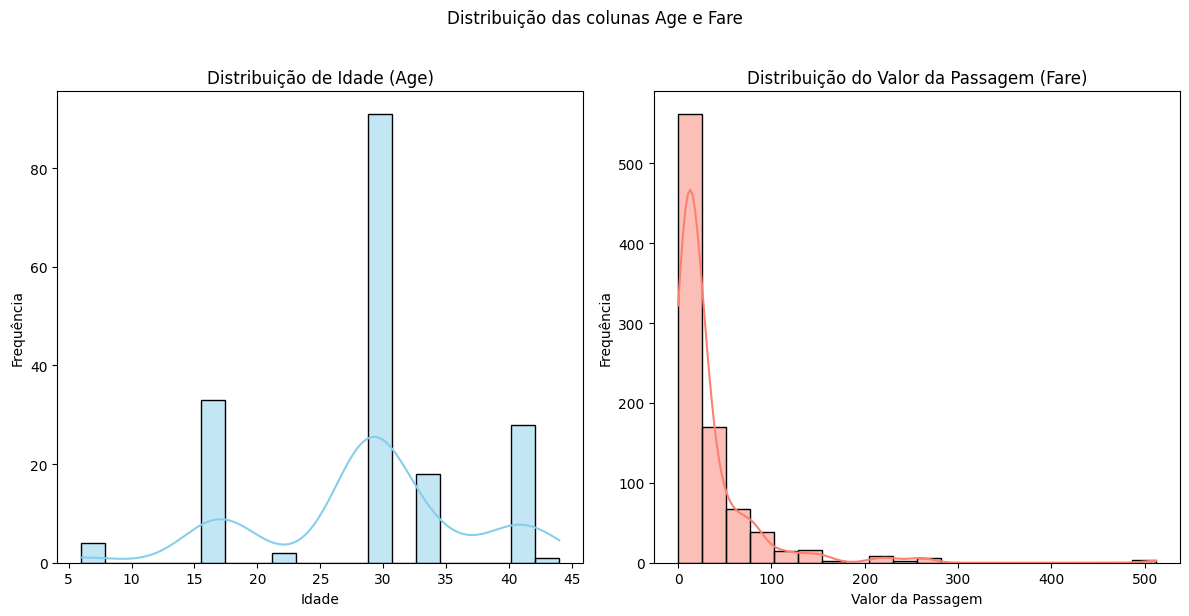

In [101]:
# Visualização da distribuição de Age e Fare
plt.figure(figsize=(12,6))
plt.suptitle('Distribuição das colunas Age e Fare', y=1.02)

plt.subplot(1,2,1)
sns.histplot(df_modelo['Age'], bins=20, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribuição de Idade (Age)')
plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.subplot(1,2,2)
sns.histplot(df_modelo['Fare'], bins=20, kde=True, color='salmon', edgecolor='black')
plt.title('Distribuição do Valor da Passagem (Fare)')
plt.xlabel('Valor da Passagem')
plt.ylabel('Frequência')

plt.tight_layout()
plt.show()

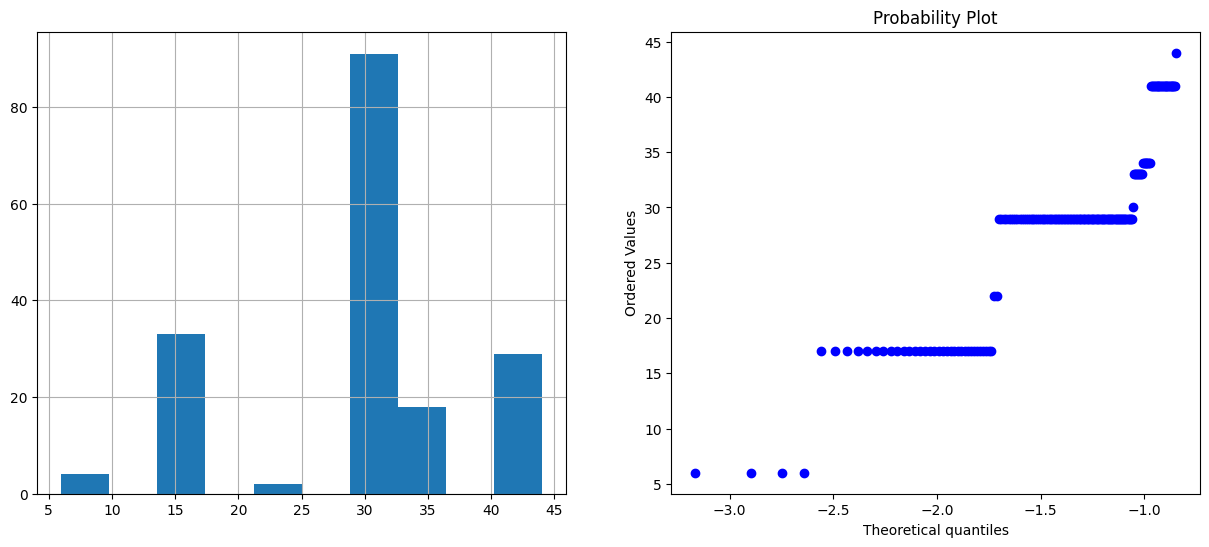

In [102]:
from scipy import stats
import pylab

def verifica_dist(df, variable):
    plt.figure(figsize=(15,6))
    plt.subplot(1,2,1)
    df[variable].hist()

    plt.subplot(1,2,2)
    stats.probplot(df[variable], dist='norm', plot=pylab)
    plt.show()

# Verificando distribuição original da idade
verifica_dist(df_train, 'Age')


Distribuição transformada da Age:


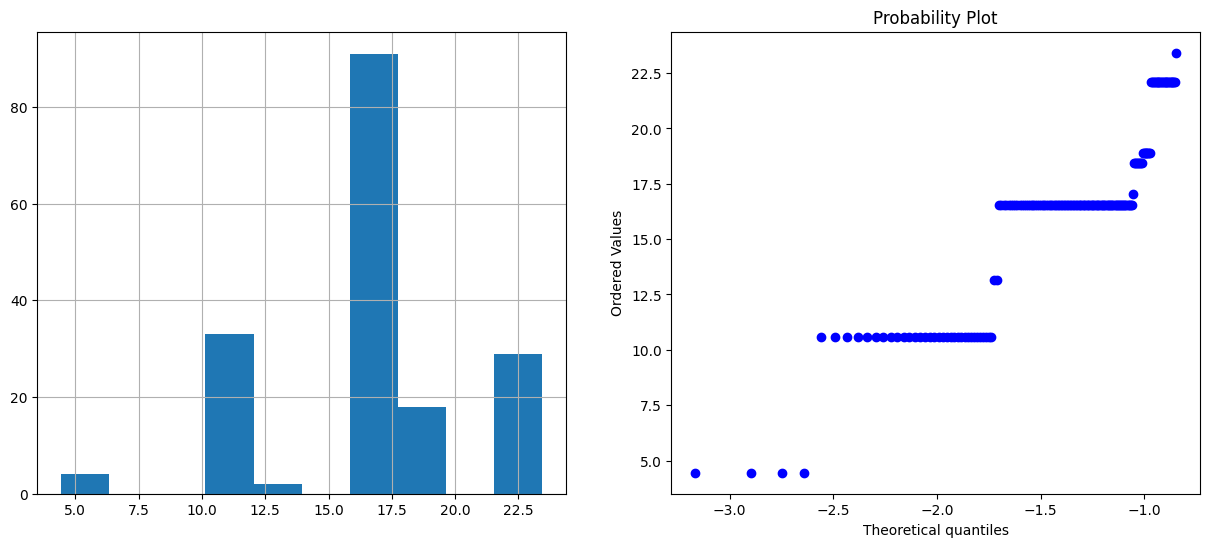


Distribuição transformada da Fare:


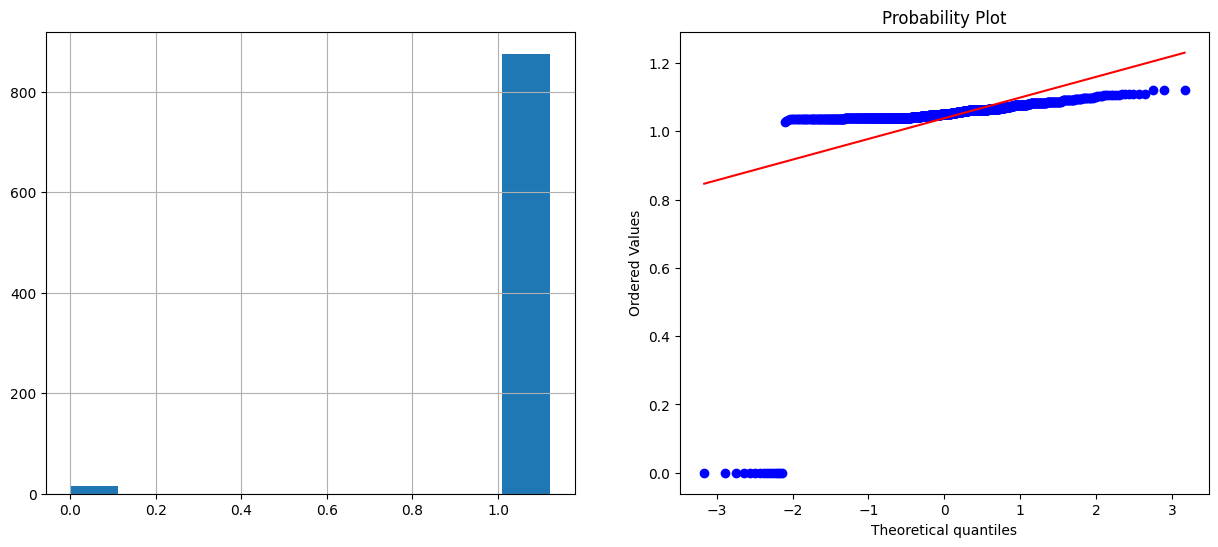

In [103]:
# Transformação das variáveis Age e Fare
df_transformado = df_train.copy()

# Aplicando transformações encontradas como ideais
df_transformado['age_quad'] = df_transformado['Age'] ** (1/1.2)
df_transformado['fare_quad'] = df_transformado['Fare'] ** (1/54)

# Verificando novas distribuições
print("\nDistribuição transformada da Age:")
verifica_dist(df_transformado, 'age_quad')

print("\nDistribuição transformada da Fare:")
verifica_dist(df_transformado, 'fare_quad')

LR: 0.8002 (0.0435)
LDA: 0.8114 (0.0482)
KNN: 0.7901 (0.0574)
CART: 0.8025 (0.0420)
NB: 0.7476 (0.0572)
SVM: 0.8227 (0.0431)
RF: 0.8014 (0.0527)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:05:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:05:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:05:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:05:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:05:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

XGB: 0.8025 (0.0451)


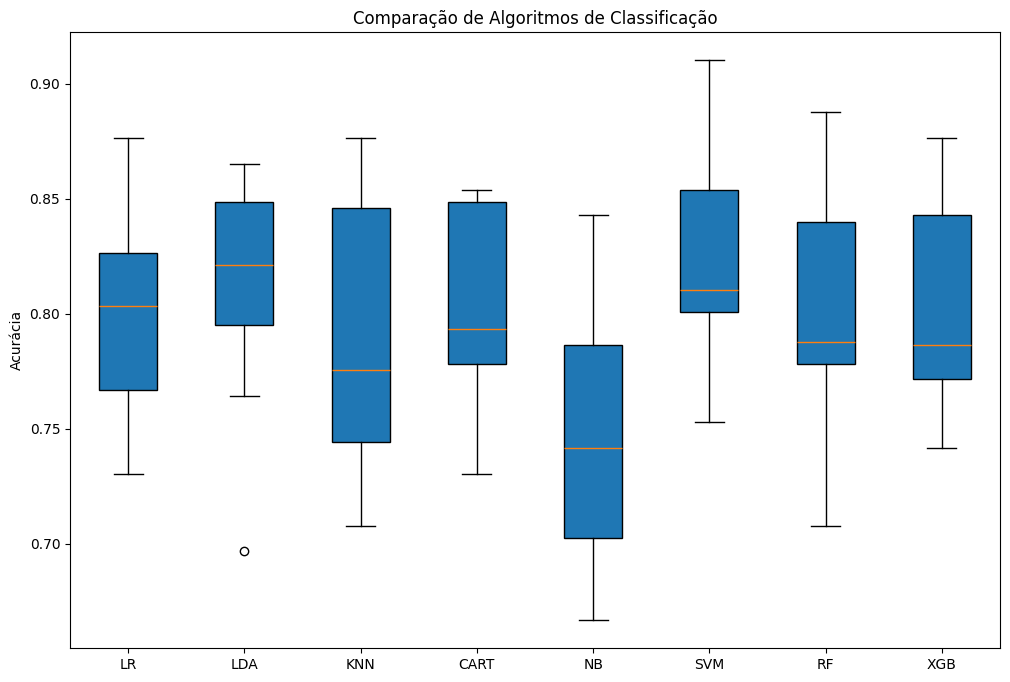

In [104]:
from sklearn.model_selection import cross_val_score, KFold

# Definindo configurações
num_folds = 10
seed = 7

# Lista de modelos
modelos = [
    ('LR', LogisticRegression()),
    ('LDA', LinearDiscriminantAnalysis()),
    ('KNN', KNeighborsClassifier()),
    ('CART', DecisionTreeClassifier()),
    ('NB', GaussianNB()),
    ('SVM', SVC(probability=True)),
    ('RF', RandomForestClassifier()),
    ('XGB', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
]

resultados = []
nomes = []

for nome, modelo in modelos:
    kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
    cv_results = cross_val_score(modelo, X_scaled, y, cv=kfold, scoring='accuracy')
    resultados.append(cv_results)
    nomes.append(nome)
    msg = "%s: %.4f (%.4f)" % (nome, cv_results.mean(), cv_results.std())
    print(msg)

plt.figure(figsize=(12,8))
plt.boxplot(resultados, patch_artist=True)
plt.xticks(range(1, len(nomes)+1), nomes)
plt.title('Comparação de Algoritmos de Classificação')
plt.ylabel('Acurácia')
plt.show()

In [106]:
#  Treinamento do modelo final (XGBoost)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Treinando XGBoost
model = xgb.XGBClassifier(
    learning_rate=0.02,
    max_depth=6,
    n_estimators=400,
    min_child_weight=2,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("\nMatriz de Confusão:\n", confusion_matrix(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:06:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       0.82      0.89      0.85       157
           1       0.82      0.73      0.77       111

    accuracy                           0.82       268
   macro avg       0.82      0.81      0.81       268
weighted avg       0.82      0.82      0.82       268


Matriz de Confusão:
 [[139  18]
 [ 30  81]]
